# Seismic Acquisition, Forward Modelling, and Traveltime Tomography Inversion

Notebook ini berisi pemodelan seismik refraksi sintetik tiga lapisan menggunakan pyGIMLi, mulai dari pembentukan model geologi, pembuatan mesh, penyusunan geometri akuisisi, forward modelling first-arrival traveltime, hingga inversi tomografi dan evaluasi data fit.

Seluruh parameter pada notebook ini merupakan konfigurasi final yang digunakan untuk menghasilkan hasil pemodelan dan inversi.


In [1]:
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
import pygimli.physics.traveltime as tt
import matplotlib.pyplot as plt
from collections import Counter

## 1. Parameter Model dan Akuisisi

Parameter berikut digunakan secara konsisten pada seluruh tahapan pemodelan, akuisisi sintetik, forward modelling, dan inversi.


In [2]:
# ============================================================
# A. KECEPATAN GELOMBANG P PER LAPISAN [m/s]
# ============================================================
VP_LAYER1 = 400.0
VP_LAYER2 = 525.0
VP_LAYER3 = 1300.0

# ============================================================
# B. PARAMETER MESH
# ============================================================
MESH_QUALITY = 34.3
MESH_AREA    = 3.0
MESH_SMOOTH  = [1, 10]

# ============================================================
# C. KONFIGURASI RECEIVER — 1 FULL-LINE SPREAD
# ============================================================
RECV_X_START = 1.5
RECV_X_END   = 166.5
RECV_SPACING = 3.0

# ============================================================
# D. KONFIGURASI SHOT — 1 FULL-LINE SPREAD
# ============================================================
SHOT_X_START = 0.0
SHOT_X_END   = 168.0
SHOT_SPACING = 3.0

# ============================================================
# E. KLASIFIKASI POSISI SHOT (1-indexed)
# ============================================================
SHOT_TYPE_RANGES = {
    'P.Near': range(1, 7),    # SH01-SH06
    'Near':   range(7, 17),   # SH07-SH16
    'Mid':    range(17, 42),  # SH17-SH41
    'Far':    range(42, 52),  # SH42-SH51
    'P.Far':  range(52, 58),  # SH52-SH57
}

# ============================================================
# F. PARAMETER NOISE SINTETIK
# ============================================================
NOISE_LEVEL = 0.001
NOISE_ABS   = 0.001
SEED        = 1337

# ============================================================
# G. PARAMETER INVERSI
# ============================================================
SEC_NODES          = 2
PARA_MAX_CELL_SIZE = 15.0
MAX_ITER           = 30


## 2. Model Geologi Sintetik

Data horizon permukaan (`top_data`) digunakan sebagai batas atas model. Domain di bawah permukaan dibagi menjadi tiga lapisan sintetis hingga batas bawah pada elevasi `BASE = 806 m`.


Interior marker points:
  Layer 1 : (84.9, 821.67)
  Layer 2 : (84.9, 815.40)
  Layer 3 : (84.9, 809.13)


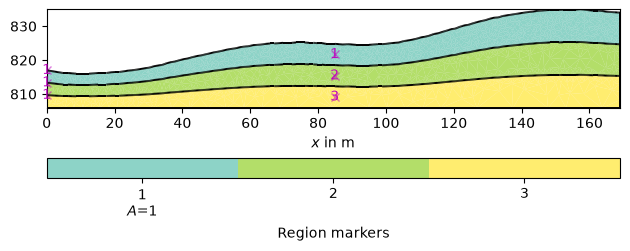

In [3]:
# -- Data horizon permukaan (X, Y_top) -----------------------------------------
top_data = np.array([
    [0.0,817],[1.2,816.8],[2.4,816.6],[3.7,816.4],[4.9,816.2],
    [6.2,816.2],[7.5,816.1],[8.7,816.0],[10.0,816.0],[11.3,816.0],
    [12.5,816.0],[13.8,816.1],[15.1,816.2],[16.3,816.2],[17.6,816.2],
    [18.9,816.4],[20.1,816.5],[21.4,816.5],[22.7,816.7],[24.0,816.9],
    [25.2,817.0],[26.5,817.2],[27.8,817.4],[29.0,817.6],[30.3,817.8],
    [31.6,818.2],[32.8,818.4],[34.1,818.6],[35.4,819.1],[36.7,819.4],
    [37.9,819.6],[39.2,820.0],[40.5,820.3],[41.7,820.5],[43.0,820.9],
    [44.3,821.2],[45.6,821.4],[46.8,821.7],[48.1,822.0],[49.4,822.3],
    [50.6,822.5],[51.9,822.8],[53.2,823.1],[54.4,823.3],[55.7,823.5],
    [57.0,823.8],[58.3,824.0],[59.5,824.1],[60.8,824.4],[62.1,824.5],
    [63.3,824.6],[64.6,824.8],[65.9,824.9],[67.1,824.9],[68.4,825.0],
    [69.7,825.1],[71.0,825.1],[72.2,825.1],[73.5,825.2],[74.8,825.2],
    [76.0,825.2],[77.3,825.1],[78.6,825.1],[79.8,825.0],[81.1,825.0],
    [82.4,824.8],[83.6,824.8],[84.9,824.8],[86.2,824.7],[87.4,824.6],
    [88.7,824.7],[90.0,824.6],[91.2,824.5],[92.5,824.5],[93.8,824.5],
    [95.0,824.5],[96.3,824.6],[97.6,824.7],[98.9,824.7],[100.1,824.8],
    [101.4,825.0],[102.7,825.1],[103.9,825.2],[105.2,825.6],[106.5,825.8],
    [107.7,826.0],[109.0,826.3],[110.3,826.7],[111.6,826.9],[112.8,827.2],
    [114.1,827.7],[115.4,827.9],[116.6,828.3],[117.9,828.7],[119.2,829.1],
    [120.5,829.3],[121.7,829.8],[123.0,830.2],[124.3,830.4],[125.5,830.8],
    [126.8,831.2],[128.1,831.5],[129.4,831.8],[130.6,832.2],[131.9,832.5],
    [133.2,832.6],[134.4,833.0],[135.7,833.2],[137.0,833.4],[138.2,833.6],
    [139.5,833.8],[140.8,834.0],[142.1,834.2],[143.3,834.3],[144.6,834.5],
    [145.9,834.6],[147.1,834.7],[148.4,834.8],[149.7,834.8],[150.9,834.8],
    [152.2,834.9],[153.5,834.9],[154.7,834.9],[156.0,834.9],[157.3,835.0],
    [158.5,834.9],[159.8,834.7],[161.1,834.6],[162.4,834.6],[163.6,834.5],
    [164.9,834.3],[166.2,834.2],[167.4,834.1],[169.0,834.0],
])

xs    = top_data[:, 0]
y_top = top_data[:, 1]
BASE  = 806.0

# -- Batas internal tiga lapisan ------------------------------------------------
y_h23 = BASE + (2.0 / 3.0) * (y_top - BASE)   # boundary Layer 1 / Layer 2
y_h12 = BASE + (1.0 / 3.0) * (y_top - BASE)   # boundary Layer 2 / Layer 3

# -- Membentuk poligon setiap lapisan ------------------------------------------
pts1 = [[x,y] for x,y in zip(xs, y_top)] + [[x,y] for x,y in zip(xs[::-1], y_h23[::-1])]
pts2 = [[x,y] for x,y in zip(xs, y_h23)] + [[x,y] for x,y in zip(xs[::-1], y_h12[::-1])]
pts3 = [[x,y] for x,y in zip(xs, y_h12)] + [[xs[-1], BASE], [xs[0], BASE]]

layer1 = mt.createPolygon(pts1, isClosed=True, addNodes=3)
layer2 = mt.createPolygon(pts2, isClosed=True, addNodes=3)
layer3 = mt.createPolygon(pts3, isClosed=True, addNodes=3)

geom = layer1 + layer2 + layer3

# -- Menetapkan region marker pada setiap lapisan -------------------------------
mid_idx = len(xs) // 2
x_mid   = xs[mid_idx]

y1_int = (y_top[mid_idx] + y_h23[mid_idx]) / 2   # inside Layer 1
y2_int = (y_h23[mid_idx] + y_h12[mid_idx]) / 2   # inside Layer 2
y3_int = (y_h12[mid_idx] + BASE)           / 2   # inside Layer 3

geom.addRegionMarker([x_mid, y1_int], marker=1, area=1)
geom.addRegionMarker([x_mid, y2_int], marker=2)
geom.addRegionMarker([x_mid, y3_int], marker=3)

print("Interior marker points:")
print(f"  Layer 1 : ({x_mid:.1f}, {y1_int:.2f})")
print(f"  Layer 2 : ({x_mid:.1f}, {y2_int:.2f})")
print(f"  Layer 3 : ({x_mid:.1f}, {y3_int:.2f})")

fig, ax = pg.show(geom)


## 3. Pembentukan Mesh

Model geometri didiskretisasi menjadi elemen-elemen segitiga menggunakan parameter mesh yang telah ditetapkan.



Mesh summary:
  Nodes : 11674
  Cells : 22639

Horizon ranges:
  y_top : 816.0 - 835.0 m
  y_h23 : 812.7 - 825.3 m
  y_h12 : 809.3 - 815.7 m
  BASE  : 806.0 m


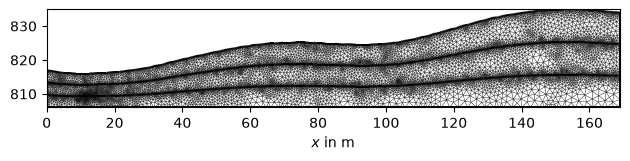

In [4]:
# -- Membentuk mesh -------------------------------------------------------------
mesh = mt.createMesh(
    geom,
    quality=MESH_QUALITY,
    area=MESH_AREA,
    smooth=MESH_SMOOTH
)

fig2, ax2 = pg.show(mesh)

# -- Ringkasan mesh -------------------------------------------------------------
print("\nMesh summary:")
print(f"  Nodes : {mesh.nodeCount()}")
print(f"  Cells : {mesh.cellCount()}")

print("\nHorizon ranges:")
print(f"  y_top : {y_top.min():.1f} - {y_top.max():.1f} m")
print(f"  y_h23 : {y_h23.min():.1f} - {y_h23.max():.1f} m")
print(f"  y_h12 : {y_h12.min():.1f} - {y_h12.max():.1f} m")
print(f"  BASE  : {BASE:.1f} m")


## 4. Geometri Akuisisi

Receiver dan shot disusun dalam satu full-line spread yang mencakup seluruh panjang lintasan. Seluruh posisi sensor mengikuti elevasi horizon permukaan.


In [5]:
def surface_y(x):
    """Interpolate Y on top horizon at position x."""
    return float(np.interp(x, top_data[:, 0], top_data[:, 1]))

# -- Posisi receiver dan shot pada satu full-line spread ------------------------
recv1 = np.arange(RECV_X_START, RECV_X_END + 0.01, RECV_SPACING)
shot1 = np.arange(SHOT_X_START, SHOT_X_END + 0.01, SHOT_SPACING)

# -- Lookup klasifikasi shot -----------------------------------------------------
SHOT_TYPE = {}
for stype, rng in SHOT_TYPE_RANGES.items():
    for sh_num in rng:
        SHOT_TYPE[sh_num] = stype

# -- Membentuk posisi sensor unik -----------------------------------------------
all_x    = np.unique(np.concatenate([recv1, shot1]))
sensors  = np.array([[x, surface_y(x)] for x in all_x])  # (N, 2)
x_to_idx = {round(x, 4): i for i, x in enumerate(all_x)}

def idx(x):
    return x_to_idx[round(x, 4)]

# -- Membentuk pasangan source-receiver -----------------------------------------
s_list, g_list, type_list = [], [], []

for sh_num, sx in enumerate(shot1, start=1):
    for rx in recv1:
        s_list.append(idx(sx))
        g_list.append(idx(rx))
        type_list.append(SHOT_TYPE[sh_num])

s_arr = pg.Vector(np.array(s_list, dtype=float))
g_arr = pg.Vector(np.array(g_list, dtype=float))

# -- Menyusun PyGIMLi DataContainer ---------------------------------------------
scheme = pg.DataContainer()

for x, y in sensors:
    scheme.createSensor(pg.Pos(x, y))

scheme.resize(len(s_list))
scheme.registerSensorIndex('s')
scheme.registerSensorIndex('g')
scheme.set('s', s_arr)
scheme.set('g', g_arr)
scheme.markValid(scheme('g') != scheme('s'))

# -- Ringkasan geometri akuisisi -------------------------------------------------
print(f"Sensors (unique) : {scheme.sensorCount()}")
print(f"Traces (total)   : {scheme.size()}")
print(f"Sensor X range   : {sensors[:,0].min():.1f} - {sensors[:,0].max():.1f} m")
print(f"Sensor Y range   : {sensors[:,1].min():.2f} - {sensors[:,1].max():.2f} m")

print("\nTraces per shot type:")
for k, v in sorted(Counter(type_list).items()):
    print(f"  {k:7s} : {v} traces")


Sensors (unique) : 113
Traces (total)   : 3192
Sensor X range   : 0.0 - 168.0 m
Sensor Y range   : 816.00 - 834.98 m

Traces per shot type:
  Far     : 560 traces
  Mid     : 1400 traces
  Near    : 560 traces
  P.Far   : 336 traces
  P.Near  : 336 traces


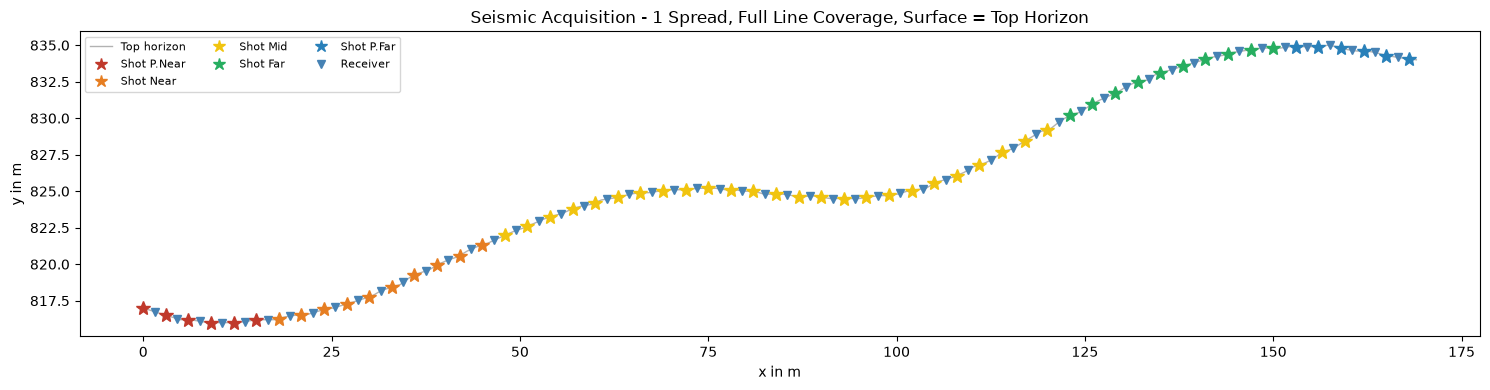

In [6]:
# -- Visualisasi geometri akuisisi ---------------------------------------------
type_colors = {
    'P.Near': '#c0392b',
    'Near':   '#e67e22',
    'Mid':    '#f1c40f',
    'Far':    '#27ae60',
    'P.Far':  '#2980b9',
}

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(top_data[:, 0], top_data[:, 1], 'k-', lw=1, alpha=0.3, label='Top horizon')

for rx in recv1:
    ax.plot(rx, surface_y(rx), 'v', color='steelblue', ms=6, zorder=3)

for sh_num, sx in enumerate(shot1, 1):
    ax.plot(sx, surface_y(sx), '*', color=type_colors[SHOT_TYPE[sh_num]], ms=10, zorder=4)

for stype, color in type_colors.items():
    ax.plot([], [], '*', color=color, ms=9, label=f'Shot {stype}')
ax.plot([], [], 'v', color='steelblue', ms=6, label='Receiver')

ax.set_xlabel('x in m')
ax.set_ylabel('y in m')
ax.set_title('Seismic Acquisition - 1 Spread, Full Line Coverage, Surface = Top Horizon')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout()
plt.show()


## 5. Model Kecepatan

Setiap region pada mesh diberikan nilai kecepatan gelombang P sesuai dengan tiga lapisan pada model sintetik.


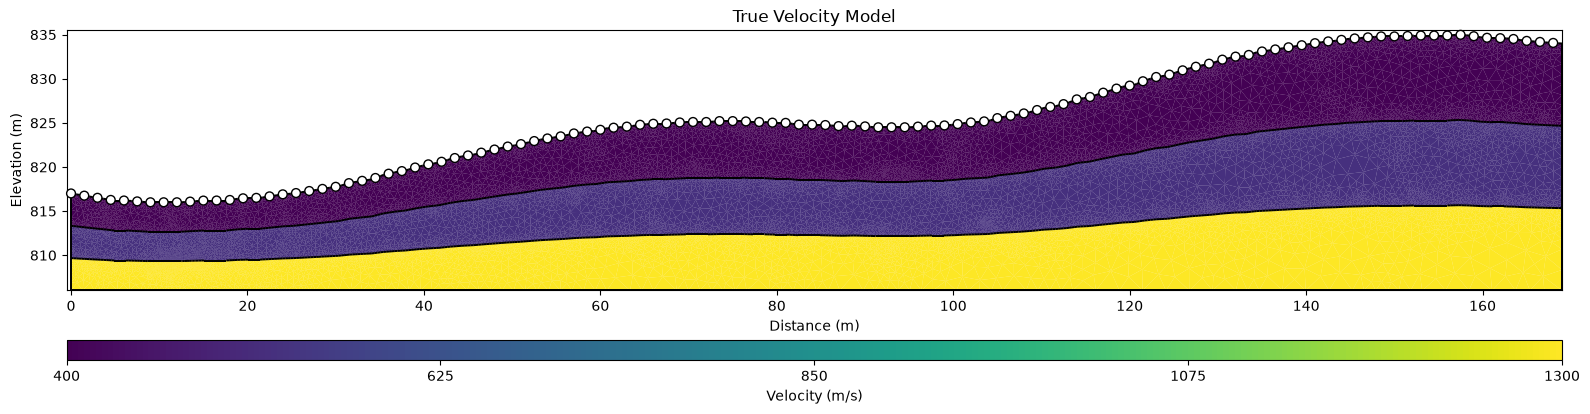

In [7]:
vp = np.array(mesh.cellMarkers(), dtype=float)
vp[vp == 1] = VP_LAYER1
vp[vp == 2] = VP_LAYER2
vp[vp == 3] = VP_LAYER3

fig, ax = plt.subplots(figsize=(16, 6))
ax, _ = pg.show(mesh, vp, colorBar=True, logScale=False, label='Velocity (m/s)', ax=ax)
pg.viewer.mpl.drawSensors(ax, scheme.sensors(), diam=1.0,
                          facecolor='white', edgecolor='black')

ax.set_title('True Velocity Model')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Elevation (m)')
plt.tight_layout()
plt.show()


## 6. Forward Modelling

First-arrival traveltime disimulasikan menggunakan model slowness, geometri akuisisi, serta parameter noise sintetik yang telah ditetapkan.


In [8]:
data = tt.simulate(
    slowness=1.0 / vp,
    scheme=scheme,
    mesh=mesh,
    noiseLevel=NOISE_LEVEL,
    noiseAbs=NOISE_ABS,
    seed=SEED,
    verbose=False
)

t = np.asarray(data('t'))

print("Synthetic traveltime summary:")
print(f"  Total traces : {data.size()}")
print(f"  t min        : {t.min():.6f} s")
print(f"  t max        : {t.max():.6f} s")
print(f"  t mean       : {t.mean():.6f} s")


05/10/26 - 22:30:17 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


Synthetic traveltime summary:
  Total traces : 3192
  t min        : 0.001153 s
  t max        : 0.184148 s
  t mean       : 0.087814 s


## 7. Visualisasi First-Arrival Traveltime


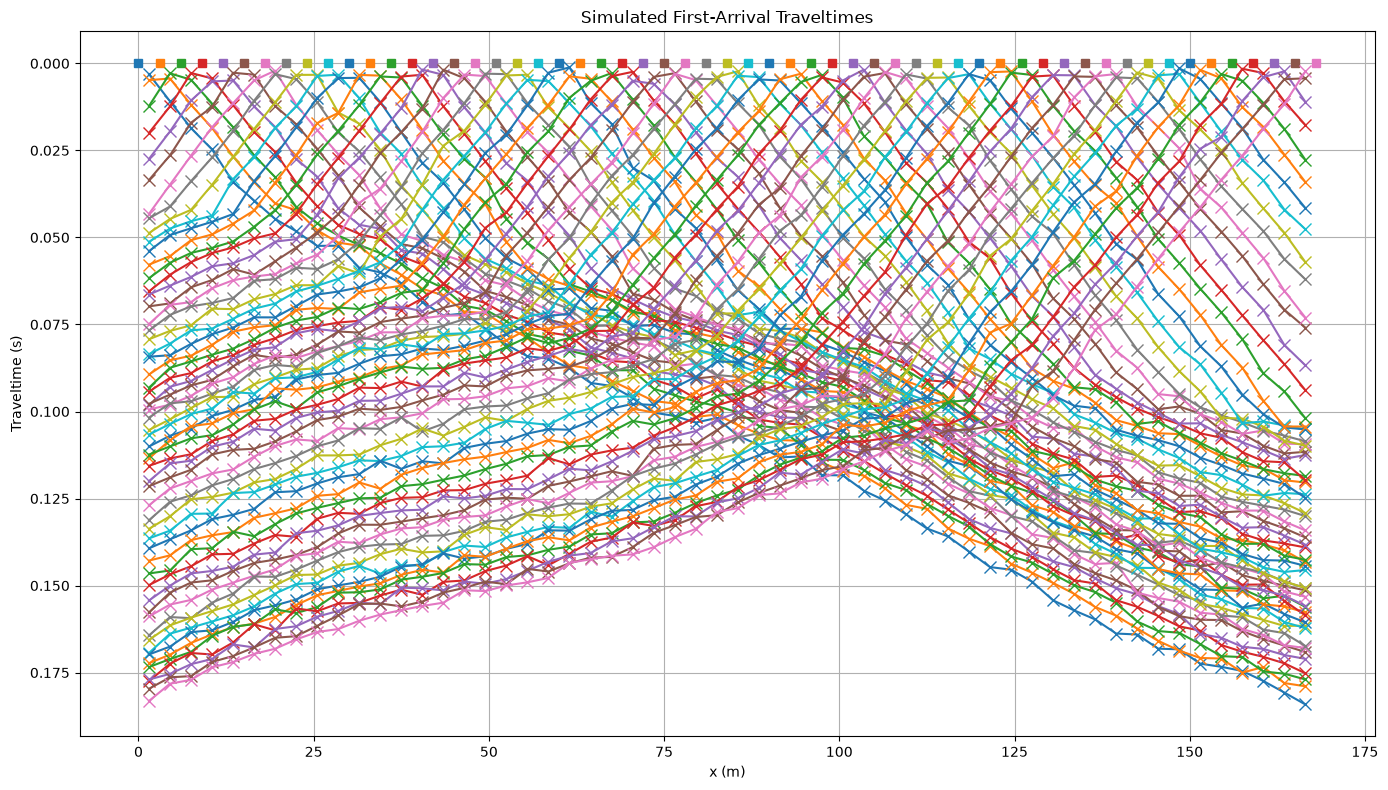

In [9]:
tt.show(data)
fig = plt.gcf()
fig.set_size_inches(14, 8)
plt.title('Simulated First-Arrival Traveltimes')
plt.tight_layout()
plt.show()


## 8. Inversi Traveltime

Data first-arrival traveltime sintetik diinversi menggunakan `TravelTimeManager` dengan parameter inversi final.


In [10]:
mgr = tt.TravelTimeManager(data)

vest = mgr.invert(
    secNodes=SEC_NODES,
    paraMaxCellSize=PARA_MAX_CELL_SIZE,
    maxIter=MAX_ITER,
    verbose=False
)

chi2 = float(mgr.inv.inv.chi2())
iteration_count = int(mgr.inv.iter)

np.testing.assert_array_less(chi2, 1.1)

print("Inversion summary:")
print(f"  Iterations       : {iteration_count} / {MAX_ITER}")
print(f"  Final chi-square : {chi2:.4f}")
print("  Status           : convergence criterion reached")


05/10/26 - 22:30:31 - pyGIMLi - INFO - Found 1 regions.
05/10/26 - 22:30:31 - pyGIMLi - INFO - Found 1 regions.
05/10/26 - 22:30:31 - pyGIMLi - INFO - Creating forward mesh from region infos.
05/10/26 - 22:30:31 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
05/10/26 - 22:30:31 - pyGIMLi - INFO - Create gradient starting model. 500: 5000


Inversion summary:
  Iterations       : 14 / 30
  Final chi-square : 1.0748
  Status           : convergence criterion reached


## 9. Hasil Inversi

Model hasil inversi ditampilkan bersama batas geometri true model. Tampilan vertikal difokuskan pada domain true model agar perbandingan lebih jelas.


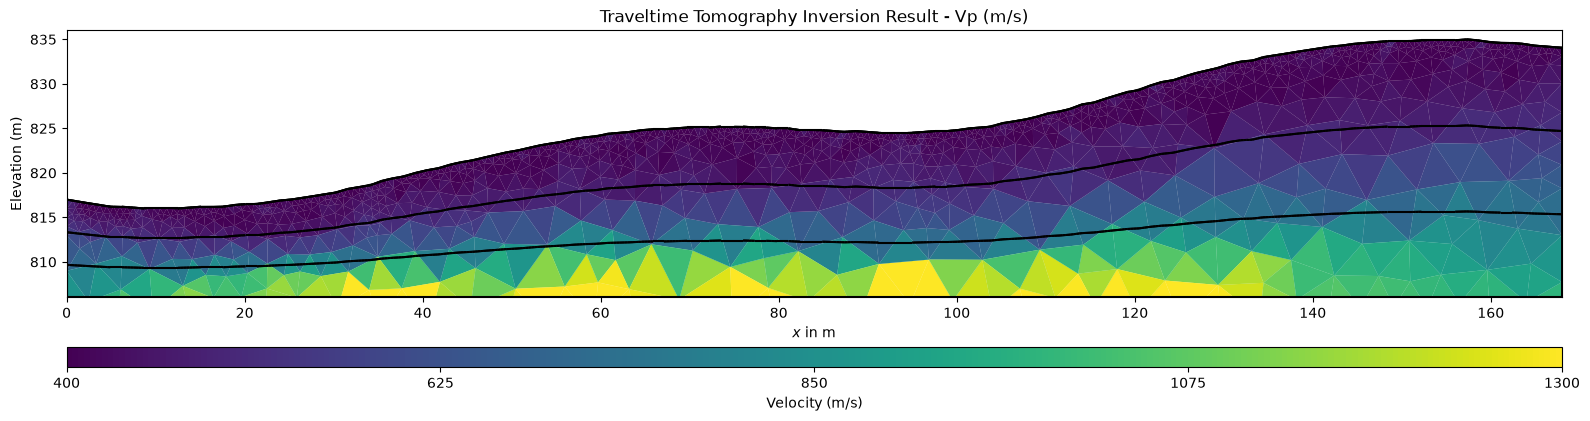

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

ax, cb = mgr.showResult(
    cMin=min(vp),
    cMax=max(vp),
    logScale=False,
    ax=ax
)

ax.set_title("Traveltime Tomography Inversion Result - Vp (m/s)")
ax.set_xlabel("x in m")
ax.set_ylabel("Elevation (m)")

# Overlay batas true model
pg.show(
    geom,
    ax=ax,
    fillRegion=False,
    regionMarker=False
)

# Fokus pada domain true model
ax.set_xlim(0, 168)
ax.set_ylim(BASE, np.max(top_data[:, 1]) + 1)

plt.tight_layout()
plt.show()


## 10. Data Fit dan Quality Control

Kesesuaian antara observed dan calculated first-arrival traveltime digunakan untuk mengevaluasi respons model hasil inversi.


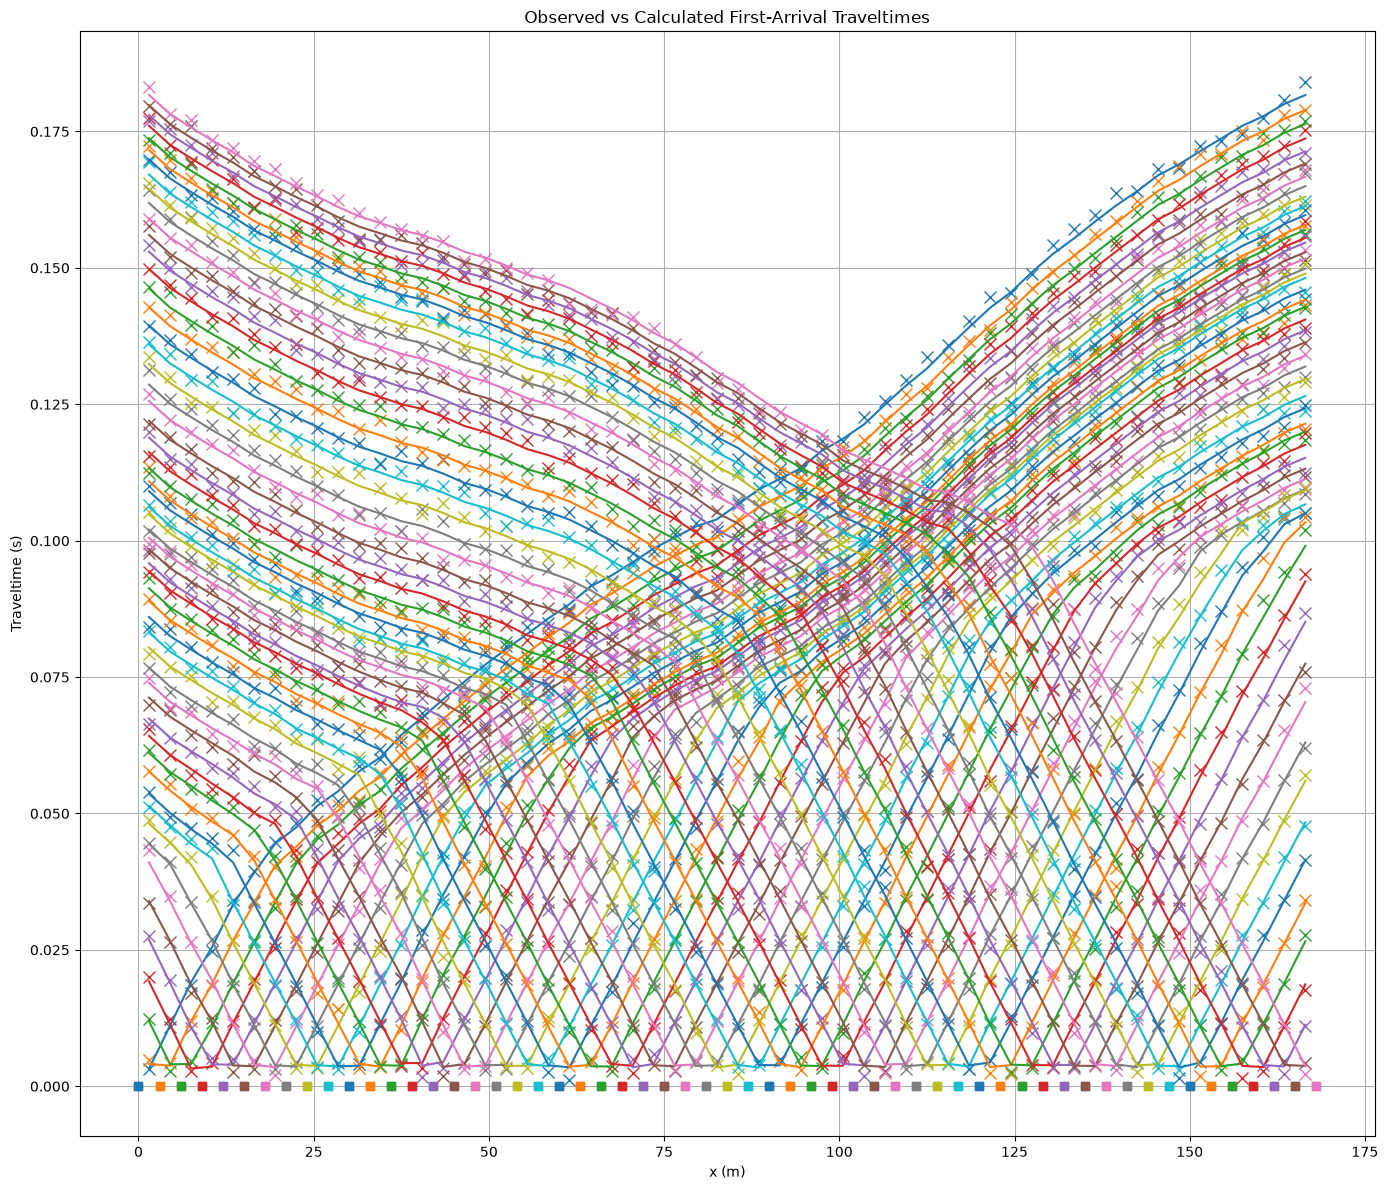

In [12]:
mgr.showFit(firstPicks=True)
fig = plt.gcf()
fig.set_size_inches(14, 12)
plt.title('Observed vs Calculated First-Arrival Traveltimes')
plt.tight_layout()
plt.show()


## 11. Ringkasan Hasil Akhir


In [13]:
print("=== FINAL MODEL SUMMARY ===")
print(f"Vp layers        : {VP_LAYER1:.0f} / {VP_LAYER2:.0f} / {VP_LAYER3:.0f} m/s")
print(f"Mesh             : {mesh.nodeCount()} nodes, {mesh.cellCount()} cells")
print(f"Receivers        : {len(recv1)}")
print(f"Shots            : {len(shot1)}")
print(f"Unique sensors   : {scheme.sensorCount()}")
print(f"Total traces     : {data.size()}")
print(f"Traveltime range : {t.min():.6f} - {t.max():.6f} s")
print(f"Iterations       : {iteration_count} / {MAX_ITER}")
print(f"Final chi-square : {chi2:.4f}")


=== FINAL MODEL SUMMARY ===
Vp layers        : 400 / 525 / 1300 m/s
Mesh             : 11674 nodes, 22639 cells
Receivers        : 56
Shots            : 57
Unique sensors   : 113
Total traces     : 3192
Traveltime range : 0.001153 - 0.184148 s
Iterations       : 14 / 30
Final chi-square : 1.0748
